### 第3章 Pandas 绘图
- `Pandas` 是面板数据(Panel Data)和Python数据分析(Python Data Analysis)的简称
- Series 对象是带索引的一维数组结构，表示一列数据
    - `pandas.Series(data, index=index)`
        - `data`：数据，支持列表、字典、NumPy数组、标量值
        - `index`：行标签索引，默认为整数序列（0 ~ data长度-1）
- DataFrame 对象是带索引的二维数组结构，表示表格型数据，包括行和列
    - `pandas.DataFrame(data, index, columns, dtype, copy)`
        - `data`：数据，可以是列表、字典、NumPy数组、Series对象等
        - `index`：行标签索引
        - `columns`：列标签索引
        - `dtype`：每一列的数据类型
            - `object`：通用数据类型，类似于Python的字典
            - `int64`：整型数据
            - `float64`：浮点型数据 
            - `bool`：布尔型数据类型，True或False
            - `datetime64`：时间戳数据类型，精确到纳秒，对应`datetime64[ns]`
            - `category`：分类数据类型，类似于Python的集合
            - `timedelta64[ns]`：时间差类型，精确到纳秒
        - `copy`：是否复制数据

In [2]:
# 导入pandas模块
import pandas as pd

# 使用列表创建Series对象
s1 = pd.Series([1, 2, 3])
print(s1)
# 使用字典创建Series对象
s2 = pd.Series({"A": 1, "B": 2, "C": 3})
print(s2)

0    1
1    2
2    3
dtype: int64
A    1
B    2
C    3
dtype: int64


In [ ]:
import pandas as pd

# 解决数据输出时列不对齐的问题
pd.set_option("display.unicode.east_asian_width", True) # 启用东亚字符宽度
# 创建数据
df = pd.DataFrame(
    {
        "姓名": ["甲", "乙", "丙"],
        "语文": [110, 105, 109],
        "数学": [105, 88, 120],
        "英语": [99, 115, 130],
    }
)
print(df)

  姓名  语文  数学  英语
0   甲   110   105    99
1   乙   105    88   115
2   丙   109   120   130


#### 实现数据可视化
- `DataFrame.plot()` 函数用于绘制 Series 对象或 DataFrame 对象的图形
- 绘制折线图 

   阅读  点赞  收藏
0   209   100    23
1   172    79    18
2   169    90     7
3   185     8     0
4   156     0     0


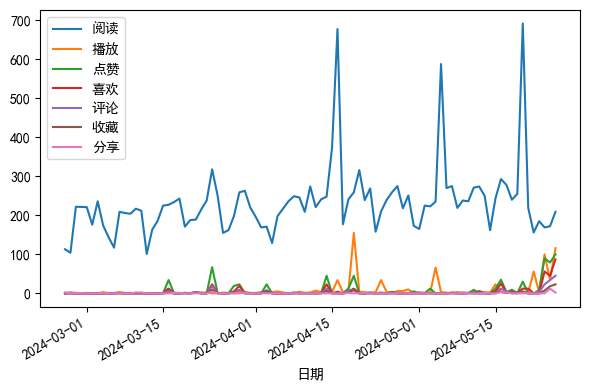

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置数据显示的编码格式为东亚宽度，以使列对齐
pd.set_option("display.unicode.east_asian_width", True)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题

# 读取Excel文件
df = pd.read_excel("../datas/日报表.xlsx")
# 抽取“阅读”、“点赞”和“收藏”列
df_chosen = df[["阅读", "点赞", "收藏"]]
print(df_chosen.head())    # 输出前5条数据

df.plot(
    x="日期",       # 设置x轴为日期
    kind="line",    # 图表类型
    legend=True,    # 显示图例
    figsize=(6, 4), # 画布大小
)  
plt.tight_layout()  # 解决图形元素显示不全的问题
plt.show()  # 显示图表

- 绘制柱形图

  月份  总店  二道分店  南关分店  朝阳分店
0  1月    20        45        28        55
1  2月    14        34        38        34
2  3月    23        56        32        28
3  4月    34        38        43        36
4  5月    56        49        26        48
5  6月    28        60        45        55


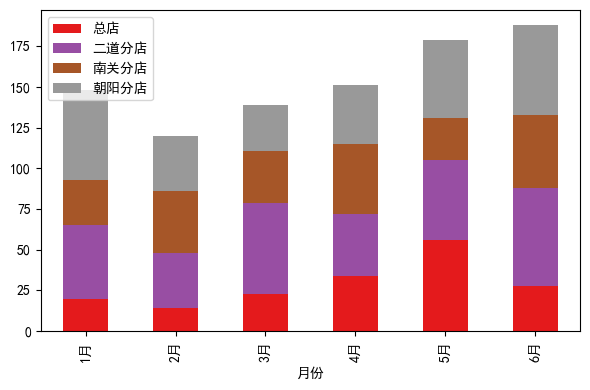

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 解决数据输出时列不对齐的问题
pd.set_option("display.unicode.east_asian_width", True)
# 创建DataFrame数据
df = pd.DataFrame(
    {
        "月份": ["1月", "2月", "3月", "4月", "5月", "6月"],
        "总店": [20, 14, 23, 34, 56, 28],
        "二道分店": [45, 34, 56, 38, 49, 60],
        "南关分店": [28, 38, 32, 43, 26, 45],
        "朝阳分店": [55, 34, 28, 36, 48, 55],
    }
)
print(df)

plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码问题
# 绘制多柱形图
df.plot(
    x="月份",
    kind="bar",     # 图表类型
    legend=True,    # 显示图例
    stacked=True,   # 堆叠柱形图, 默认False
    colormap="Set3",   # 配色方案: "Paired", "Accent", "Dark2", "Set1", "Set2", "Set3"
    figsize=(6, 4), # 画布大小
)  
plt.tight_layout()
plt.show()

- 绘制饼图

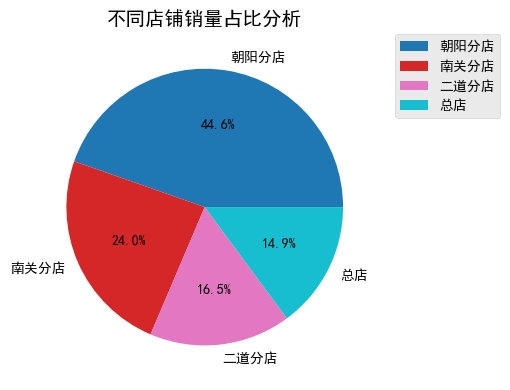

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 解决数据输出时列不对齐的问题
pd.set_option("display.unicode.east_asian_width", True)
# 创建DataFrame数据
df = pd.DataFrame(
    {
        "月份": ["1月", "2月", "3月", "1月", "2月", "3月", "1月", "2月", "3月", "1月", "2月", "3月"],
        "店铺名称": ["总店", "总店", "总店", 
                    "南关分店", "南关分店", "南关分店",
                    "二道分店", "二道分店", "二道分店",
                    "朝阳分店", "朝阳分店", "朝阳分店"],
        "销量": [50, 88, 42, 64, 128, 98, 34, 99, 67, 52, 255, 233],
    }
)
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码问题
# 统计结果按销量降序排序绘制饼形图
df.groupby("店铺名称").sum().sort_values(by="销量", ascending=False).plot(
    y="销量",           # y轴数据
    kind="pie",         # 饼形图
    autopct="%.1f%%",   # 百分比保留小数点后1位
    colormap="tab10",   # 每块饼图的颜色
    figsize=(6, 4),      # 设置图表大小
)  

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)  # 设置图例
plt.title("不同店铺销量占比分析", fontsize=14, fontweight="bold")  # 图表标题
plt.tight_layout()
plt.show()